In [1]:
# %% [markdown]
# # PlayStation sales, margins, and demographics analysis
# Demo notebook: UK / Manchester focus; linear regression + basic NLP.

# %% [code]
# 1. Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Linear regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# NLP
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Optional: for more advanced NLP (spaCy, etc.)
# import spacy
# nlp = spacy.load("en_core_web_sm")  # ensure model installed

# Set plotting style
sns.set(style="whitegrid")

In [2]:
# %% [code]
# Synthetic dataset creation for demonstration
np.random.seed(42)

n = 500
dates = pd.date_range(start="2023-01-01", periods=n, freq="D")
cities = ["Manchester", "London", "Birmingham", "Glasgow", "Leeds"]
age_groups = ["18-24", "25-34", "35-44", "45-54", "55+"]

df_demo = pd.DataFrame({
    "Date": np.random.choice(dates, size=n),
    "City": np.random.choice(cities, size=n, p=[0.3,0.2,0.2,0.15,0.15]),
    "Sales": np.random.gamma(shape=2.0, scale=1500.0, size=n),
    "Cost": np.random.gamma(shape=2.0, scale=1000.0, size=n),
    "AgeGroup": np.random.choice(age_groups, size=n, p=[0.2,0.35,0.25,0.1,0.1]),
    "Comments": np.random.choice([
        "Great deal, loved the service!",
        "Too expensive compared to competitors.",
        "Fast download, smooth gameplay.",
        "Customer support was very helpful.",
        "Had issues with billing, but resolved quickly."
    ], size=n)
})

# Calculate profit margin
df_demo["ProfitMargin"] = (df_demo["Sales"] - df_demo["Cost"]) / df_demo["Sales"]

df_demo.head()

,Date,City,Sales,Cost,AgeGroup,Comments,ProfitMargin
0,2023-04-13,Manchester,4477.302852,371.050193,35-44,"Great deal, loved the service!",0.917126
1,2024-03-11,Birmingham,1181.641290,3885.770740,25-34,"Had issues with billing, but resolved quickly.",-2.288452
2,2023-12-15,Leeds,3546.980123,1050.915034,18-24,"Great deal, loved the service!",0.703716
3,2023-09-28,Glasgow,3203.397630,7631.051586,55+,Too expensive compared to competitors.,-1.382174
4,2023-04-17,Birmingham,2012.959830,4555.433299,25-34,"Fast download, smooth gameplay.",-1.263052


In [3]:
# %% [code]
# Choose dataset: replace df_demo with df if using real data
data = df_demo.copy()

# Convert date
data["Date"] = pd.to_datetime(data["Date"])

# Drop or flag missing values
data = data.dropna(subset=["Sales", "Cost", "ProfitMargin"])

# Add month or year as features
data["Month"] = data["Date"].dt.month
data["Year"] = data["Date"].dt.year

# Example: filter to Manchester if needed
manchester_data = data[data["City"] == "Manchester"].copy()

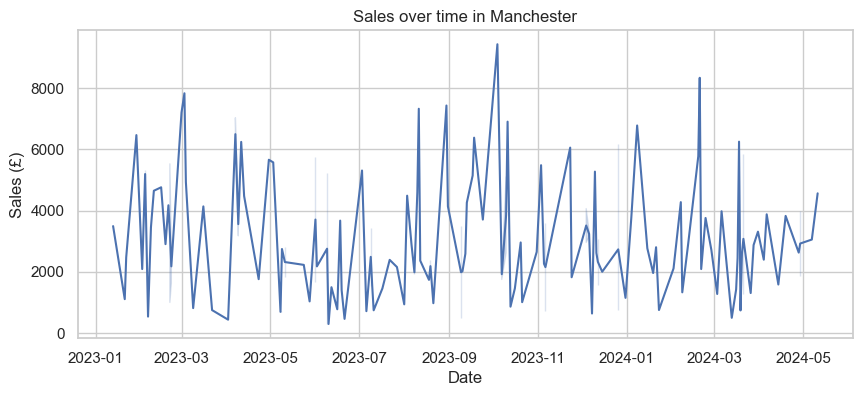

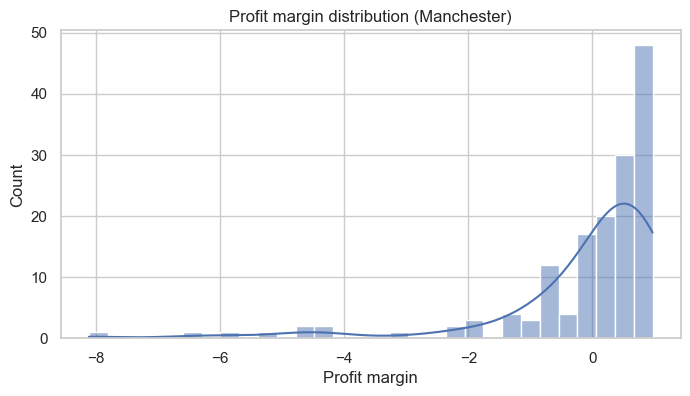

In [4]:
# %% [code]
# Sales over time for Manchester
plt.figure(figsize=(10,4))
sns.lineplot(data=manchester_data.sort_values("Date"), x="Date", y="Sales")
plt.title("Sales over time in Manchester")
plt.ylabel("Sales (£)")
plt.show()

# Profit margin distribution
plt.figure(figsize=(8,4))
sns.histplot(manchester_data["ProfitMargin"], bins=30, kde=True)
plt.title("Profit margin distribution (Manchester)")
plt.xlabel("Profit margin")
plt.show()

In [5]:
# %% [code]
# Select features for modelling (example)
features = ["Month", "Year"]  # drop or add numeric encodings for categorical features
# One-hot encode City or AgeGroup if needed
data_model = pd.get_dummies(manchester_data, columns=["AgeGroup"], drop_first=True)

# Add numeric features to list
features += [col for col in data_model.columns if col.startswith("AgeGroup_")]

X = data_model[features]
y = data_model["Sales"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R^2: {r2:.3f}")

MSE: 6042302.79
R^2: -0.341


In [6]:
# %% [code]
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", key=lambda col: col.abs(), ascending=False)

coef_df.head(10)

,Feature,Coefficient
5,AgeGroup_55+,-2599.046212
4,AgeGroup_45-54,-1846.813972
2,AgeGroup_25-34,-1603.271498
3,AgeGroup_35-44,-1041.387799
0,Month,-60.020678
1,Year,-53.089141


In [7]:
# %% [code]
# Similar setup but with y = ProfitMargin
y_margin = data_model["ProfitMargin"]

X_train, X_test, y_train, y_test = train_test_split(X, y_margin, test_size=0.2, random_state=42)

lr_margin = LinearRegression()
lr_margin.fit(X_train, y_train)

y_pred_margin = lr_margin.predict(X_test)

print("Profit margin model")
print("MSE:", mean_squared_error(y_test, y_pred_margin))
print("R^2:", r2_score(y_test, y_pred_margin))

Profit margin model
MSE: 4.438085166955284
R^2: -0.10046977734176288


In [8]:
# %% [code]
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data_model["CleanComments"] = data_model["Comments"].astype(str).apply(clean_text)

In [9]:
# %% [code]
vectorizer = TfidfVectorizer(
    max_features=500,  # limit vocabulary for demo
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(data_model["CleanComments"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (152, 18)


In [10]:
# %% [code]
svd = TruncatedSVD(n_components=5, random_state=42)
lsa_features = svd.fit_transform(tfidf_matrix)

# Show top terms per component
terms = vectorizer.get_feature_names_out()
for i, comp in enumerate(svd.components_):
    top_terms = [terms[idx] for idx in comp.argsort()[-10:][::-1]]
    print(f"Component {i}: {', '.join(top_terms)}")

Component 0: service, loved, deal, great, resolved, quickly, issues, billing, fast, download
Component 1: customer, support, helpful, service, loved, great, deal, billing, issues, quickly
Component 2: competitors, expensive, compared, customer, support, helpful, deal, service, loved, great
Component 3: gameplay, download, fast, smooth, customer, helpful, support, expensive, compared, competitors
Component 4: billing, resolved, quickly, issues, smooth, download, fast, gameplay, helpful, customer


In [11]:
# %% [code]
# Add LSA topic scores to model features
lsa_cols = [f"Topic_{i}" for i in range(lsa_features.shape[1])]
lsa_df = pd.DataFrame(lsa_features, columns=lsa_cols, index=data_model.index)
data_model = pd.concat([data_model, lsa_df], axis=1)

# Example: model Sales using LSA topics + earlier features
features_extended = features + lsa_cols
X_ext = data_model[features_extended]
y_ext = data_model["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X_ext, y_ext, test_size=0.2, random_state=42)

lr_ext = LinearRegression()
lr_ext.fit(X_train, y_train)
print("Extended model R^2:", r2_score(y_test, lr_ext.predict(X_test)))

Extended model R^2: -0.3203430116493422
